# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 03 — Étude du momentum pur (vectoriel)

**Rôle de cette phase.** Avant de figer les stratégies finales, on mène une petite **étude de recherche** sur le momentum pur : on compare plusieurs fenêtres de calcul (*lookback*) pour voir laquelle marche le mieux, en version vectorielle (rapide, adaptée à l'exploration). On explore **deux définitions** du momentum :

- le **momentum cross-sectional** (transversal) — celui qu'on retiendra pour le rapport ;
- le **momentum série temporelle** (time-series) — présenté à part, pour bien comprendre la différence.

La meilleure fenêtre cross-sectional issue de cette étude sera ensuite **intégrée au moteur événementiel** (Phase 4) pour la comparaison finale équitable de la Phase 5, avec coûts et mêmes règles que les autres stratégies.

> On travaille en **rééquilibrage mensuel** : on décide en fin de mois, on détient le mois suivant. Le momentum est une logique de moyenne fréquence, ce qui rend le vectoriel fiable ici.


## 0. Données et cadre commun

On charge les cours figés (Phase 0), on passe en **fréquence mensuelle** (dernier cours de chaque mois) et on calcule les rendements mensuels. Tout le reste s'appuie sur ces deux objets.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True; plt.rcParams["grid.alpha"] = 0.3

adj = pd.read_csv("../data/adj_close.csv", index_col=0, parse_dates=True)
UNIVERSE = ["AAPL", "MSFT", "NVDA", "AMZN", "JPM", "XOM", "JNJ", "PG"]
px = adj[UNIVERSE]

monthly_px  = px.resample("ME").last()      # dernier cours de chaque mois
monthly_ret = monthly_px.pct_change()        # rendement mensuel
print("Cours mensuels :", monthly_px.shape, "| période :",
      monthly_px.index.min().date(), "->", monthly_px.index.max().date())

WINDOWS = [1, 3, 6, 12]   # fenêtres de lookback en mois
TOP_K = 3                  # nb de titres achetés (cross-sectional), top 3 sur 8
ANN = 12                   # annualisation mensuelle

Cours mensuels : (200, 8) | période : 2010-01-31 -> 2026-08-31


In [2]:
def perf_monthly(monthly_ret, ann=12):
    r = monthly_ret.dropna()
    eq = (1 + r).cumprod()
    years = len(r) / ann
    cagr = eq.iloc[-1] ** (1 / years) - 1
    vol = r.std() * np.sqrt(ann)
    sharpe = r.mean() / r.std() * np.sqrt(ann) if r.std() > 0 else np.nan
    dd = (eq / eq.cummax() - 1).min()
    return {"CAGR": cagr, "Volatilité": vol, "Sharpe": sharpe,
            "Max drawdown": dd, "Équité finale": eq.iloc[-1]}, eq

## PARTIE A — Momentum cross-sectional (transversal)

**L'idée.** Chaque fin de mois, on classe les 8 titres **les uns par rapport aux autres** selon leur performance sur les N derniers mois, et on achète les `TOP_K` meilleurs, à poids égal. On garde un mois, puis on reclasse. C'est une logique **relative** : on détient toujours quelque chose (les « meilleurs du moment »), même en marché baissier.

**Anti look-ahead.** Le classement de fin de mois *t* utilise uniquement l'information jusqu'à *t*, et sert à détenir le portefeuille **pendant le mois *t+1***. En code, on décale les poids d'un mois (`weights.shift(1)`) avant de les multiplier aux rendements du mois suivant.


In [3]:
def cross_sectional_momentum(monthly_px, monthly_ret, N, top_k):
    lookback = monthly_px.pct_change(N)                 # perf sur N mois, à chaque fin de mois
    ranks = lookback.rank(axis=1, ascending=False)      # 1 = meilleur
    weights = (ranks <= top_k).astype(float)
    weights = weights.div(weights.sum(axis=1), axis=0)  # poids égal parmi les sélectionnés
    strat_ret = (weights.shift(1) * monthly_ret).sum(axis=1)  # shift = anti look-ahead
    return strat_ret.iloc[N + 1:]                        # on retire la période de chauffe

cs_results = {}
cs_curves = {}
for N in WINDOWS:
    r = cross_sectional_momentum(monthly_px, monthly_ret, N, TOP_K)
    metrics, eq = perf_monthly(r)
    cs_results[f"{N} mois"] = metrics
    cs_curves[f"{N} mois"] = eq

cs_table = pd.DataFrame(cs_results).T
print(f"Momentum cross-sectional — top {TOP_K} sur {len(UNIVERSE)} titres, rééquilibrage mensuel")
cs_table.round(3)

Momentum cross-sectional — top 3 sur 8 titres, rééquilibrage mensuel


,CAGR,Volatilité,Sharpe,Max drawdown,Équité finale
1 mois,0.296,0.206,1.372,-0.394,71.731
3 mois,0.325,0.214,1.432,-0.285,98.976
6 mois,0.300,0.209,1.368,-0.266,67.634
12 mois,0.261,0.205,1.243,-0.302,36.937


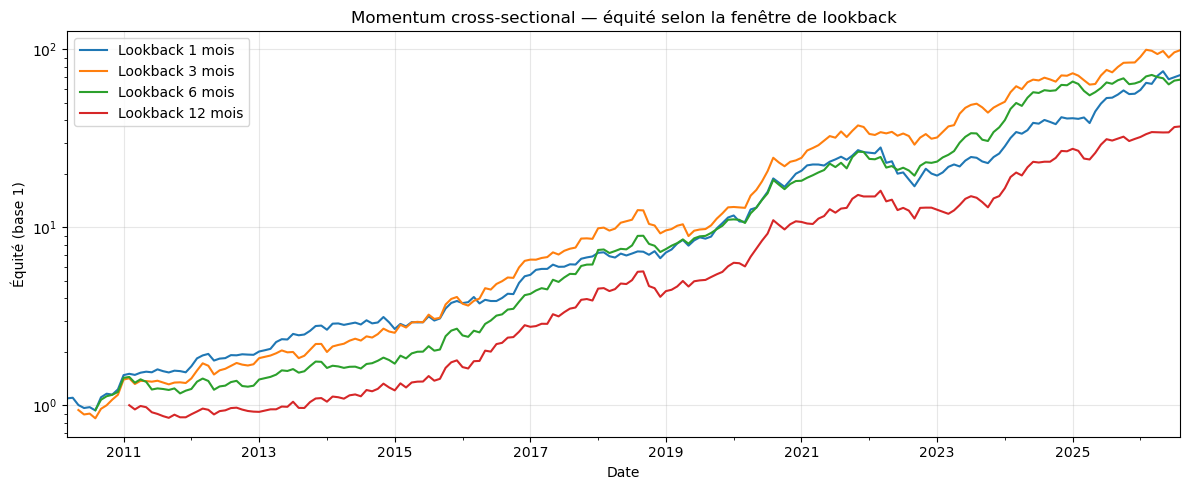

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, eq in cs_curves.items():
    eq.plot(ax=ax, label=f"Lookback {label}", lw=1.5)
ax.set_title("Momentum cross-sectional — équité selon la fenêtre de lookback")
ax.set_ylabel("Équité (base 1)"); ax.set_yscale("log"); ax.legend(); plt.tight_layout(); plt.show()

### Choix de la meilleure fenêtre cross-sectional
On retient la fenêtre au meilleur Sharpe : c'est elle qu'on intégrera au moteur événementiel pour la Phase 5.


In [5]:
best_cs = cs_table["Sharpe"].idxmax()
print(f"Meilleure fenêtre cross-sectional (Sharpe) : {best_cs}")
print(cs_table.loc[best_cs].round(3).to_string())

Meilleure fenêtre cross-sectional (Sharpe) : 3 mois
CAGR              0.325
Volatilité        0.214
Sharpe            1.432
Max drawdown     -0.285
Équité finale    98.976


## PARTIE B — Momentum série temporelle (time-series)

**L'idée, et la différence clé.** Ici, chaque titre est comparé **à son propre passé**, indépendamment des autres : s'il a monté sur les N derniers mois (momentum positif) → on le détient ; sinon → on n'en veut pas. C'est une logique **absolue**. Conséquence majeure : si *tous* les titres ont un momentum négatif, on se retrouve **entièrement en cash** — impossible dans la version cross-sectional, qui détient toujours les « moins pires ».

On équipondère les titres à momentum positif à chaque date. Cette partie est ici pour la **compréhension** ; c'est la version cross-sectional (Partie A) qui ira au rapport.


In [6]:
def time_series_momentum(monthly_px, monthly_ret, N):
    lookback = monthly_px.pct_change(N)
    signal = (lookback > 0).astype(float)               # long si momentum absolu positif
    weights = signal.div(signal.sum(axis=1).replace(0, np.nan), axis=0).fillna(0.0)
    strat_ret = (weights.shift(1) * monthly_ret).sum(axis=1)
    return strat_ret.iloc[N + 1:], signal

ts_results = {}
ts_curves = {}
cash_frac = {}
for N in WINDOWS:
    r, signal = time_series_momentum(monthly_px, monthly_ret, N)
    metrics, eq = perf_monthly(r)
    ts_results[f"{N} mois"] = metrics
    ts_curves[f"{N} mois"] = eq
    active = signal.iloc[N + 1:].sum(axis=1)
    cash_frac[f"{N} mois"] = (active == 0).mean()        # % du temps 100% cash

ts_table = pd.DataFrame(ts_results).T
ts_table["% temps 100% cash"] = pd.Series(cash_frac)
print("Momentum série temporelle — long si momentum positif, sinon cash")
ts_table.round(3)

Momentum série temporelle — long si momentum positif, sinon cash


,CAGR,Volatilité,Sharpe,Max drawdown,Équité finale,% temps 100% cash
1 mois,0.225,0.195,1.142,-0.248,28.425,0.035
3 mois,0.239,0.166,1.383,-0.163,33.022,0.010
6 mois,0.285,0.177,1.515,-0.194,56.255,0.000
12 mois,0.218,0.159,1.325,-0.222,21.544,0.000


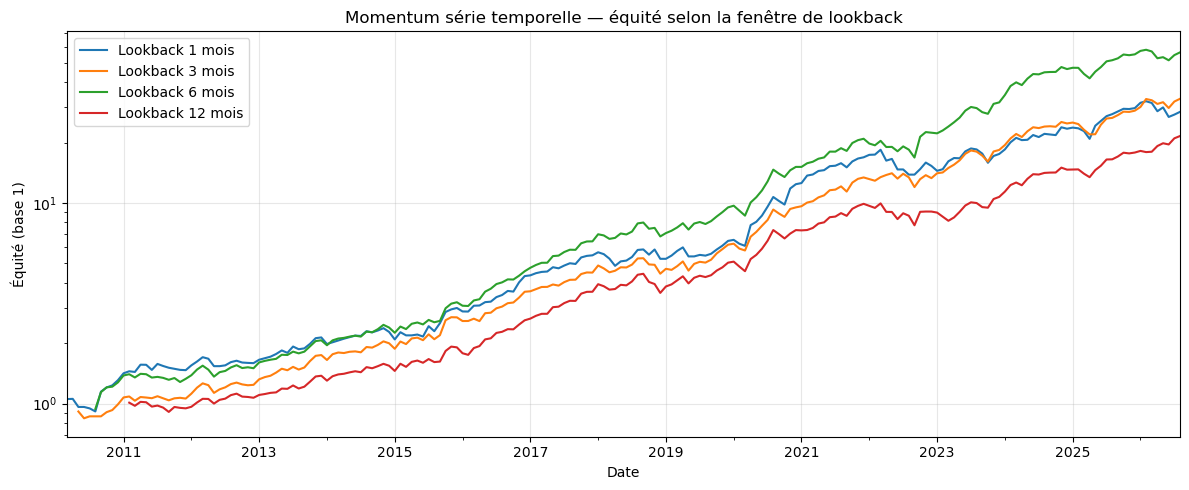

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for label, eq in ts_curves.items():
    eq.plot(ax=ax, label=f"Lookback {label}", lw=1.5)
ax.set_title("Momentum série temporelle — équité selon la fenêtre de lookback")
ax.set_ylabel("Équité (base 1)"); ax.set_yscale("log"); ax.legend(); plt.tight_layout(); plt.show()

## Comparaison des deux approches et des benchmarks

On confronte, sur la meilleure fenêtre de chaque approche, les deux définitions du momentum à deux références : le portefeuille **équipondéré** (détenir les 8 titres à parts égales, rééquilibré mensuellement) et **SPY** (buy & hold de l'indice).


In [8]:
# Benchmarks mensuels
ew_ret  = monthly_ret.mean(axis=1).iloc[1:]                       # équipondéré 8 titres
spy_ret = adj["SPY"].resample("ME").last().pct_change().iloc[1:]  # SPY buy & hold

best_ts = ts_table["Sharpe"].idxmax()

rows = {
    f"Cross-sectional ({best_cs})": perf_monthly(
        cross_sectional_momentum(monthly_px, monthly_ret, int(best_cs.split()[0]), TOP_K))[0],
    f"Série temporelle ({best_ts})": perf_monthly(
        time_series_momentum(monthly_px, monthly_ret, int(best_ts.split()[0]))[0])[0],
    "Équipondéré 8 titres": perf_monthly(ew_ret)[0],
    "SPY buy & hold": perf_monthly(spy_ret)[0],
}
compare = pd.DataFrame(rows).T
compare.round(3)

,CAGR,Volatilité,Sharpe,Max drawdown,Équité finale
Cross-sectional (3 mois),0.325,0.214,1.432,-0.285,98.976
Série temporelle (6 mois),0.285,0.177,1.515,-0.194,56.255
Équipondéré 8 titres,0.232,0.160,1.398,-0.214,31.989
SPY buy & hold,0.146,0.144,1.028,-0.239,9.644


## Ce qu'on retient

- **Cross-sectional vs série temporelle** : le premier est *relatif* (toujours investi dans les meilleurs), le second *absolu* (peut sortir totalement en cash). Le tableau « % temps 100% cash » de la Partie B rend cette différence concrète.
- **La fenêtre de lookback compte** : les Sharpe varient nettement selon N. On a identifié la meilleure fenêtre cross-sectional, qu'on emmène en Phase 4.
- **Prudence statistique** : avec seulement 8 titres, cette étude est **illustrative**, pas une preuve robuste. On le dira clairement dans le rapport (petit univers, risque de sur-apprentissage sur le choix de N).
- **Attention aux coûts (Phase 3)** : le momentum **tourne beaucoup** (reclassement mensuel, entrées/sorties fréquentes). C'est exactement le type de stratégie dont la performance peut s'effondrer une fois les coûts inclus. On le vérifiera en Phase 3 sur ces stratégies.

**Prochaine étape — Phase 3 : coûts de transaction et slippage**, appliqués au SMA **et** au momentum, pour voir si le classement des stratégies survit aux frais.
